In [1]:
import pandas as pd
import spacy
import re

In [2]:
nlp=spacy.load('en_core_web_sm')
pd.set_option('display.max_colwidth', None)


In [3]:
data = [
    "When life gives you lemons, make lemonade! 🙂",
    "She bought 2 lemons for $1 at Maven Market.",
    "A dozen lemons will make a gallon of lemonade. [AllRecipes]",
    "lemon, lemon, lemons, lemon, lemon, lemons",
    "He's running to the market to get a lemon — there's a great sale today.",
    "Does Maven Market carry Eureka lemons or Meyer lemons?",
    "An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]",
    "iced tea is my favorite"
]
test = [
    "We're going to start this course with traditional NLP applications.",
    "Then we'll move on to modern NLP theory.",
    "Finally, we'll wrap things up with modern NLP applications."
]

In [4]:
df=pd.DataFrame(data,columns=["Sentence"])
sr=pd.Series(test)

In [5]:
df

,Sentence
0,"When life gives you lemons, make lemonade! 🙂"
1,She bought 2 lemons for $1 at Maven Market.
2,A dozen lemons will make a gallon of lemonade. [AllRecipes]
3,"lemon, lemon, lemons, lemon, lemon, lemons"
4,He's running to the market to get a lemon — there's a great sale today.
5,Does Maven Market carry Eureka lemons or Meyer lemons?
6,"An Arnold Palmer is half lemonade, half iced tea. [Wikipedia]"
7,iced tea is my favorite


In [6]:
sr

0    We're going to start this course with traditional NLP applications.
1                               Then we'll move on to modern NLP theory.
2            Finally, we'll wrap things up with modern NLP applications.
dtype: object

In [7]:
def lower_pun(text):
    text=text.lower()
    text=re.sub(r'[^\w\s]', '', text)
    return text

In [8]:
df['Sentence'] = df['Sentence'].apply(lower_pun)

In [9]:
df

,Sentence
0,when life gives you lemons make lemonade
1,she bought 2 lemons for 1 at maven market
2,a dozen lemons will make a gallon of lemonade allrecipes
3,lemon lemon lemons lemon lemon lemons
4,hes running to the market to get a lemon theres a great sale today
5,does maven market carry eureka lemons or meyer lemons
6,an arnold palmer is half lemonade half iced tea wikipedia
7,iced tea is my favorite


In [10]:
sr=sr.apply(lower_pun)

In [11]:
sr

0    were going to start this course with traditional nlp applications
1                               then well move on to modern nlp theory
2             finally well wrap things up with modern nlp applications
dtype: object

In [12]:
def token_lemme_stop(text):
    doc=nlp(text)
    output=[token.lemma_ for token in doc if not token.is_stop]
    output=' '.join(output)
    return output

In [13]:
df['preProcessedSentence']=df['Sentence'].apply(token_lemme_stop)

In [14]:
df

,Sentence,preProcessedSentence
0,when life gives you lemons make lemonade,life give lemon lemonade
1,she bought 2 lemons for 1 at maven market,buy 2 lemon 1 maven market
2,a dozen lemons will make a gallon of lemonade allrecipes,dozen lemon gallon lemonade allrecipe
3,lemon lemon lemons lemon lemon lemons,lemon lemon lemon lemon lemon lemon
4,hes running to the market to get a lemon theres a great sale today,s run market lemon s great sale today
5,does maven market carry eureka lemons or meyer lemons,maven market carry eureka lemon meyer lemon
6,an arnold palmer is half lemonade half iced tea wikipedia,arnold palmer half lemonade half ice tea wikipedia
7,iced tea is my favorite,ice tea favorite


In [15]:
prsr=sr.apply(token_lemme_stop)

In [16]:
prsr

0    go start course traditional nlp application
1                              modern nlp theory
2      finally wrap thing modern nlp application
dtype: object

In [17]:
def lower_pun(text):
    text=text.lower()
    text=re.sub(r'[^\w\s]', '', text)
    return text
def token_lemme_stop(text):
    doc=nlp(text)
    output=[token.lemma_ for token in doc if not token.is_stop]
    output=' '.join(output)
    return output
def pos(text,):
    doc=nlp(text)
    output=[token.text for token in doc if token.pos_ in ['NOUN', 'PROPN']]
    output=' '.join(output)
    return output


## NLP PipeLine

In [18]:
def nlp_pipeline(series):
    output=series.apply(lower_pun)
    output=output.apply(token_lemme_stop)
    output=output.apply(pos)
    return output


In [19]:
result_series=nlp_pipeline(sr)
result_series

0          nlp application
1               nlp theory
2    thing nlp application
dtype: object

In [20]:
df['preprocessedText']=nlp_pipeline(df['Sentence'])
df['preprocessedText']

0                       life lemon lemonade
1                        lemon maven market
2     dozen lemon gallon lemonade allrecipe
3       lemon lemon lemon lemon lemon lemon
4                 s market lemon sale today
5           maven market eureka lemon lemon
6    palmer lemonade half ice tea wikipedia
7                          ice tea favorite
Name: preprocessedText, dtype: object

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
dtm=cv.fit_transform(df.preprocessedText)
dtm_df=pd.DataFrame(dtm.toarray(),columns=cv.get_feature_names_out())


In [22]:
dtm_df

,allrecipe,dozen,eureka,favorite,gallon,half,ice,lemon,lemonade,life,market,maven,palmer,sale,tea,today,wikipedia
0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0
2,1,1,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0
5,0,0,1,0,0,0,0,2,0,0,1,1,0,0,0,0,0
6,0,0,0,0,0,1,1,0,1,0,0,0,1,0,1,0,1
7,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0


In [23]:
cv2=CountVectorizer(stop_words='english',min_df=0.2,max_df=0.8,ngram_range=(1,2))       
## here min_df is the percentage
#that is a word should be in minimum 20 percent of the documenst 
dtm2=cv2.fit_transform(df.preprocessedText)
dtm_df2=pd.DataFrame(dtm2.toarray(),columns=cv2.get_feature_names_out())

In [24]:
dtm_df2

,ice,ice tea,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0,0,1,0,1,0,0,0,0
1,0,0,1,0,0,1,1,1,0
2,0,0,1,0,1,0,0,0,0
3,0,0,6,5,0,0,0,0,0
4,0,0,1,0,0,1,0,0,0
5,0,0,2,1,0,1,1,1,0
6,1,1,0,0,1,0,0,0,1
7,1,1,0,0,0,0,0,0,1


### EDA ->Exploratory Data Analysis

In [25]:
freq_texts=dtm_df2.sum()

In [26]:
freq_texts

ice              2
ice tea          2
lemon           12
lemon lemon      6
lemonade         3
market           3
maven            2
maven market     2
tea              2
dtype: int64

<Axes: >

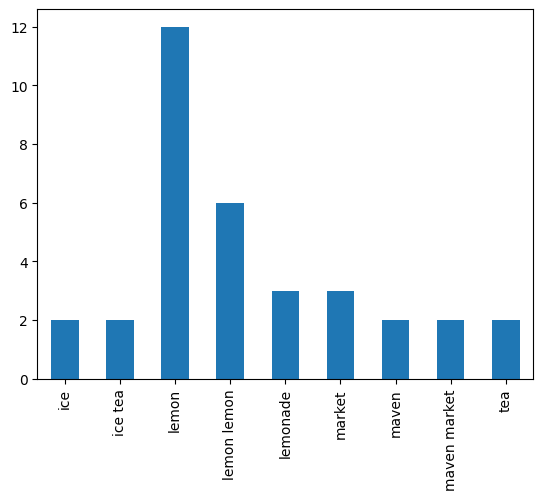

In [27]:
freq_texts.plot(kind='bar')

<Axes: >

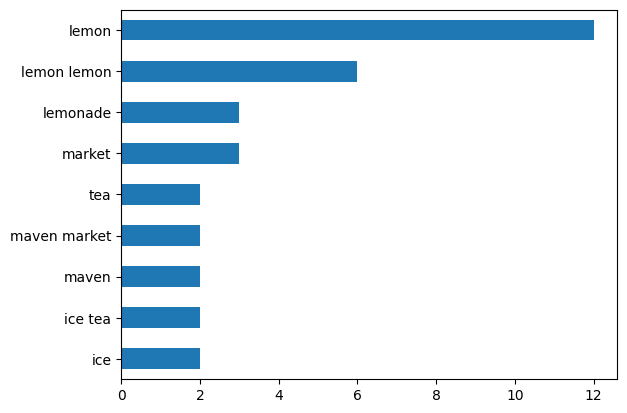

In [28]:
freq_texts.sort_values().plot(kind='barh')

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',ngram_range=(1,2),min_df=2)
tfv_mat=tfidf.fit_transform(df.preprocessedText)
tfv_mat_df=pd.DataFrame(tfv_mat.toarray(),columns=tfidf.get_feature_names_out())

In [33]:
tfv_mat_df

,ice,ice tea,lemon,lemon lemon,lemonade,market,maven,maven market,tea
0,0.000000,0.000000,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.338644,0.000000,0.000000,0.490093,0.567948,0.567948,0.000000
2,0.000000,0.000000,0.568471,0.000000,0.822704,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.581897,0.813262,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.568471,0.000000,0.000000,0.822704,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.524634,0.439939,0.000000,0.379631,0.439939,0.439939,0.000000
6,0.516768,0.516768,0.000000,0.000000,0.445928,0.000000,0.000000,0.000000,0.516768
7,0.577350,0.577350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.577350
